# Why cross-model agreement flags logic errors: consensus mechanism audit (demo)

This notebook is a runnable demo of the **T4 consensus-mechanism audit** (`eval.py`) from a study of
**gold-free quality metrics for natural-language → first-order-logic (NL→FOL) translation**.

**The question.** Several LLM families translate the same sentence into FOL. One way to score a candidate without a gold
formula is to check whether translations from *other* vendor families are logically equivalent to it (z3-checked, up to
predicate alignment). This gives a graded **consensus score** `c_score_align`: the share of peer families that
*disagree* with the candidate, so higher means more suspicious. The binary version is **majority endorsement**
(`END_MAJ`: the candidate is endorsed if `c < 0.5`).

**What the audit shows.** For any binary endorsement rule there is an exact bookkeeping identity

$$\mathrm{AUROC}_b = 1 - \frac{e + d}{2},\qquad e = P(\text{endorsed}\mid\text{ERROR}),\quad d = P(\text{not endorsed}\mid\text{CORRECT}).$$

- `e` is **error endorsement**: wrong translations that happen to agree with the peers.
- `d` is **correct divergence**: right translations that the peers do not reproduce, because of different vocabulary or granularity.

On the full data set (2,672 scorable rows of dataset E, regime R_AB), the graded score `c_score_align` reaches AUROC
**0.784**, while binary `END_MAJ` reaches **0.669** (e = 0.124, d = 0.537). Binary consensus **degrades with sentence
length**, and `d` drives that (NET Δ(e+d) words T3−T1 = +0.356).

**What this demo runs.** The expensive, input-heavy stage of `eval.py` is precomputed. It is the label-free z3 pairwise
equivalence matrix over 29,107 output pairs (`src/run_matrix.py`, which needs the vendored `eqmv` code and about 60 MB of
upstream datasets). The demo starts from its per-row outputs (consensus scores + labels) for a curated **100-row subset**
of `full_eval_out.json`. On those rows it re-runs the original analysis code, copied from `src/stats.py`,
`src/mechanism.py`, `src/part_a.py` and `eval.py`:
1. the exact e/d decomposition per endorsement rule (with the identity asserted);
2. graded vs binary AUROC, with a sentence-cluster bootstrap CI on the difference;
3. the graded ROC trace with its named operating points;
4. the NET test: does binary consensus get better or worse with sentence length?

At the end, the demo's numbers are compared with the full-run numbers that ship in the data file.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (the original script logs with it)
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

## Imports

The first block is the original `eval.py` import block. The original script also re-executed itself with
`PYTHONHASHSEED=0` and set a 20 GB `RLIMIT_AS`. Both are left out here: the hash seed matters only for the z3 aligner in
the (precomputed) matrix stage, and the demo uses a few MB of RAM. The second block holds the imports of the helper
modules `src/stats.py` and `src/mechanism.py`, whose functions are copied below, plus matplotlib for the plots.

In [2]:
# --- original eval.py imports
import argparse
import json
import os
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

# --- imports used by the copied helpers (src/stats.py, src/mechanism.py)
import re
import warnings
from collections import Counter, defaultdict

from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression

# --- notebook additions (plots)
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-3/evaluation-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["evaluation_name"])
print(data["metadata"]["selection"])
print(f"{len(data['examples'])} example rows, {len(data['metrics_agg_full'])} full-run metrics for comparison")

Do wrong translations scatter? Consensus mechanism audit (T4 on dataset E) + verified record
100 consensus-scorable R_AB rows: 50 sentences with both labels, stratified over strata L25/L20/EXC/CTRL, one ERROR + one CORRECT row per sentence, numpy default_rng(0)
100 example rows, 335 full-run metrics for comparison


## Configuration

All tunable parameters. The original run used `B = 2000` sentence-cluster bootstrap replicates with
`numpy.random.default_rng(0)` on all 2,672 scorable R_AB rows (292 sentences). The mini data file holds 100 rows
(50 sentences), which is the most this demo can use.

In [5]:
B_BOOT = 2000        # sentence-cluster bootstrap replicates (original: 2000)
BOOT_SEED = 0        # original: numpy default_rng(0)
N_ROWS = 100         # rows of the mini data used (max 100 here; original: 2,672 scorable R_AB rows from full_eval_out.json)

## Build the consensus-scorable population frame `P`

In `src/part_a.py`, `P` is the set of R_AB rows (tier A+B labels, LLM systems) that are parseable and have a consensus
score. Each example row in `eval_out.json` carries the columns needed to rebuild it:

| eval_out field | P column | meaning |
|---|---|---|
| `output` | `y_AB` | 1 = ERROR, 0 = CORRECT (the prover-checked label) |
| `predict_c_score_align` | `c_frozen` | graded consensus: share of peer families that do **not** endorse the candidate (FROZEN, from exp 5) |
| `predict_c_score_exact` | `c_score_exact` | the same score with the predicate aligner switched off |
| `predict_b_endmaj` etc. | `end_MAJ`, … | binary flags *b = 1 − endorsed*, so `end_X = 1 − predict_b_X` |

This cell is the only new glue code. The rest is the original functions.

In [6]:
ex = data["examples"][:N_ROWS]
rows = []
for e in ex:
    inp = json.loads(e["input"])
    rows.append({"row_key": e["metadata_row_key"], "sentence_id": e["metadata_sentence_id"], "text": inp["text"],
                 "candidate_fol": inp["candidate_fol"], "family_vendor": inp["family"], "stratum": inp["stratum"],
                 "final_label": e["output"], "y_AB": 1 if e["output"] == "ERROR" else 0,
                 "c_frozen": float(e["predict_c_score_align"]), "c_score_exact": float(e["predict_c_score_exact"]),
                 "end_MAJ": 1 - int(float(e["predict_b_endmaj"])), "end_PLUR": 1 - int(float(e["predict_b_endplur"])),
                 "end_FAM2": 1 - int(float(e["predict_b_endfam2"])), "end_FAMMAJ": 1 - int(float(e["predict_b_endfammaj"])),
                 "words": e["metadata_words"], "n_conditions": e["metadata_n_conditions"], "label_tier": e["metadata_tier"],
                 "vocab_exact": e["metadata_vocab_exact"], "correct_not_equivalent": e["metadata_correct_not_equivalent"],
                 "exception_type": None})  # exception_type is not exported per row; only used for an extra cut in make_bins
P = pd.DataFrame(rows)
P["in_RAB"] = True
P["end_MAJ_EXACT"] = (P.c_score_exact < 0.5).astype(int)   # as in part_a.py: END_MAJ on the aligner-free score
print(P.shape, P.y_AB.value_counts().to_dict(), "sentences:", P.sentence_id.nunique())
P[["sentence_id", "stratum", "family_vendor", "final_label", "c_frozen", "end_MAJ", "words", "n_conditions", "candidate_fol"]].head(6)

(100, 22) {1: 50, 0: 50} sentences: 50


,sentence_id,stratum,family_vendor,final_label,c_frozen,end_MAJ,words,n_conditions,candidate_fol
0,0735186af337,CTRL,mistral,ERROR,0.000000,1,6,0,"SupportedBy(williamDickinson, portlandWhigs)"
1,0735186af337,CTRL,qwen,CORRECT,0.000000,1,6,0,"Supported(williamDickinson, portlandWhigs)"
2,8863f5f99f1c,CTRL,qwen,ERROR,1.000000,0,6,1,∀d (Disease(d) → ∃x (Female(x) ∨ Male(x) ∧ Aff...
3,8863f5f99f1c,CTRL,mistral,CORRECT,0.636364,0,6,1,"∀x (Disease(x) → (Affects(x, females) ∨ Affect..."
4,113b00880c5c,CTRL,meta,ERROR,0.200000,1,12,0,"Play(psyche) ∧ BasedOn(psyche, jamesMirandaBarry)"
5,113b00880c5c,CTRL,deepseek,CORRECT,0.166667,1,12,0,"Play(psyche) ∧ BasedOn(psyche, lifeOfJamesMira..."


## Shared statistics (`src/stats.py`, copied unchanged)

- `auc`: Mann-Whitney AUROC with ties counted as 0.5 (identical to sklearn's `roc_auc_score`).
- `strat_auc`: within-stratum pair AUROC.
- `SentBoot`: the **sentence-cluster bootstrap**, stored as multiplicity weights. Rows from the same sentence are
  correlated (several systems translate the same sentence), so whole sentences are resampled.
- `WAuc`: AUROC under those bootstrap weights, so a CI needs no refitting.

In [7]:
B_DEFAULT = 2000


def auc(y, s) -> float:
    """Mann-Whitney AUROC with ties = 0.5 (identical to sklearn roc_auc_score)."""
    y = np.asarray(y, dtype=float)
    s = np.asarray(s, dtype=float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auc(y, s, strata) -> float:
    """Within-stratum pair AUROC: sum_s w_s AUROC_s with w_s = n_err,s * n_cor,s (exp 5 'stratified')."""
    y, s, strata = np.asarray(y, float), np.asarray(s, float), np.asarray(strata)
    num = den = 0.0
    for st in np.unique(strata):
        m = strata == st
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


def ci(vals, lo=2.5, hi=97.5):
    v = np.asarray([x for x in vals if x is not None and not np.isnan(x)], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


# ------------------------------------------------------------------ weighted (bootstrap-count) statistics
class WAuc:
    """AUROC under row weights (bootstrap multiplicities); ties = 0.5. Precomputes the score ranking once."""

    def __init__(self, y, s):
        self.y = np.asarray(y, float)
        vals, self.inv = np.unique(np.asarray(s, float), return_inverse=True)
        self.nv = len(vals)

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        W1 = np.bincount(self.inv, weights=w * self.y, minlength=self.nv)
        W0 = np.bincount(self.inv, weights=w * (1 - self.y), minlength=self.nv)
        den = W1.sum() * W0.sum()
        if den <= 0:
            return float("nan")
        cum0 = np.cumsum(W0) - W0
        return float((W1 * (cum0 + 0.5 * W0)).sum() / den)


class SentBoot:
    """Sentence-cluster bootstrap as multiplicity weights: W[b, i] = #times row i's sentence was drawn in replicate b
    (numpy default_rng(seed); sentence_ids resampled with replacement)."""

    def __init__(self, sids, b: int = B_DEFAULT, seed: int = 0):
        sids = np.asarray(sids)
        self.keys, self.sent_ix = np.unique(sids, return_inverse=True)
        S = len(self.keys)
        rng = np.random.default_rng(seed)
        self.C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        self.B = b

    def weights(self, b: int, mask=None):
        w = self.C[b][self.sent_ix]
        return w if mask is None else w[mask]

    def W(self, mask=None):
        """(B, n_rows[mask]) weight matrix."""
        W = self.C[:, self.sent_ix]
        return W if mask is None else W[:, mask]

## The e/d decomposition and graded trace (`src/mechanism.py`, copied unchanged)

- `ed_decomposition(y, endorsed)` is the reusable function this artifact ships. It returns `e`, `d` and `AUROC_b`, and
  **asserts** the identity `AUROC_b = 1 − (e+d)/2`. This is balanced accuracy: a binary flag has one ROC point, so its
  AUROC is fixed entirely by its two error rates.
- `graded_trace(y, c)` sweeps every threshold of the graded score (`flag = c ≥ t`) and records `(e_t, d_t)`. It
  asserts that the trapezoid area equals the AUROC. It also reports three named operating points: *any peer agrees*,
  *majority* (= END_MAJ) and *all peers agree*.
- `prereg_cuts` / `make_bins` build the pre-registered complexity bins: word-count terciles and `n_conditions` bins.

In [8]:
RULES = ["MAJ", "PLUR", "FAM2", "FAMMAJ", "MAJ_EXACT"]
MIN_ROWS, MIN_SENT = 30, 10


# =================================================================================================== identity
def ed_decomposition(y, endorsed) -> dict:
    """y: 1 = ERROR, 0 = CORRECT; endorsed: 1 = the cross-family peer rule endorses the candidate.
    Returns e = P(endorsed | ERROR) (error-endorsement), d = P(not endorsed | CORRECT) (correct-divergence) and
    AUROC_b of b = 1 - endorsed, asserting the bookkeeping identity AUROC_b = 1 - (e + d)/2 (balanced accuracy)."""
    y = np.asarray(y, int)
    en = np.asarray(endorsed, int)
    e = float(en[y == 1].mean())
    d = float((1 - en[y == 0]).mean())
    a = auc(y, 1 - en)
    assert abs(a - (1 - (e + d) / 2)) < 1e-12, (a, e, d)
    return {"n_err": int((y == 1).sum()), "n_cor": int((y == 0).sum()), "e": e, "d": d, "auroc_b": a}


# =================================================================================================== bins
def make_bins(df: pd.DataFrame, cut: dict) -> pd.DataFrame:
    q1, q2 = cut["words_tercile_cuts"]
    df = df.copy()
    df["words_t"] = np.where(df.words <= q1, "T1", np.where(df.words <= q2, "T2", "T3"))
    nc = df.n_conditions.fillna(-1).astype(int)
    df["ncond_bin"] = np.where(nc <= 1, "0-1", np.where(nc == 2, "2", np.where(nc == 3, "3", "4+")))
    et = df.exception_type.fillna("none").astype(str)
    keep = set(cut["exception_types_kept"])
    df["exc_bin"] = np.where(et == "none", "none", np.where(et.isin(keep), et, "other_exc"))
    df["long"] = df.stratum.isin(["L25", "L20", "EXC"])
    return df


def prereg_cuts(rab: pd.DataFrame) -> dict:
    sent = rab.drop_duplicates("sentence_id")
    q1, q2 = np.quantile(sent.words.values, [1 / 3, 2 / 3])
    et = rab.exception_type.fillna("none").astype(str)
    cnt = Counter(et[et != "none"])
    return {"words_tercile_cuts": [float(q1), float(q2)], "words_tercile_rule": "T1: words<=q1, T2: q1<words<=q2, T3: >q2; "
            "cut points = 1/3, 2/3 quantiles of R_AB SENTENCE words (np.quantile, linear)",
            "n_conditions_bins": ["0-1", "2", "3", "4+"], "exception_types_kept": sorted(k for k, v in cnt.items() if v >= 30),
            "exception_type_counts_R_AB_rows": dict(cnt)}


# =================================================================================================== graded trace
def graded_trace(y, c) -> dict:
    """(e_t, d_t) at every distinct threshold t of the graded score (flag = c >= t); the ROC = (d_t, 1 - e_t).
    Asserts the trapezoid area equals the tie-aware AUROC to 1e-9."""
    y = np.asarray(y, int)
    c = np.asarray(c, float)
    ts = np.unique(c)
    pts = [(0.0, 0.0)]
    tr = []
    for t in ts[::-1]:
        fl = c >= t
        tpr = fl[y == 1].mean()
        fpr = fl[y == 0].mean()
        tr.append({"t": float(t), "e_t": float(1 - tpr), "d_t": float(fpr)})
        pts.append((fpr, tpr))
    pts.append((1.0, 1.0))
    xs, ys = zip(*pts)
    area = float(np.trapezoid(ys, xs))
    a = auc(y, c)
    assert abs(area - a) < 1e-9, (area, a)
    named = {}
    for nm, en in (("any_peer_agrees (c<1)", c < 1), ("majority END_MAJ (c<0.5)", c < 0.5), ("all_peers_agree (c==0)", c == 0)):
        named[nm] = {"e": float(en[y == 1].mean()), "d": float((~en)[y == 0].mean()),
                     "auroc_b": float(1 - (en[y == 1].mean() + (~en)[y == 0].mean()) / 2)}
    return {"trace": tr, "trapezoid_area": area, "auroc": a, "named_points": named}

### NET test helpers (`src/mechanism.py`, copied unchanged)

`net_test` asks the label-specific question. Going from the shortest to the longest word-count tercile (and from
`n_conditions` 0–1 to 4+), does `e + d` fall (errors scatter more, so consensus **improves**) or rise (correct
translations diverge more, so it **degrades**)? It gives a sentence-cluster bootstrap CI on Δ(e+d). It also gives the
summed average marginal effect per SD from logistic refits in every bootstrap replicate. Those refits are the slow part
at large `B_BOOT`.

In [9]:
def zcols(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d["zn"] = (d.n_conditions - d.n_conditions.mean()) / d.n_conditions.std()
    d["zw"] = (d.words - d.words.mean()) / d.words.std()
    return d


# =================================================================================================== NET
def _ame(X: np.ndarray, yv: np.ndarray, w: np.ndarray, j: int) -> float:
    m = LogisticRegression(C=1e6, max_iter=500).fit(X, yv, sample_weight=w)
    p = m.predict_proba(X)[:, 1]
    return float(np.average(m.coef_[0][j] * p * (1 - p), weights=w))


def net_test(P: pd.DataFrame, boot: SentBoot, col: str = "end_MAJ", long_only: bool = False) -> dict:
    """Delta(e+d) top vs bottom words tercile (and n_conditions 4+ vs 0-1) with cluster-bootstrap CIs, plus the summed
    average marginal effect per SD (AME_e + AME_d) from plain logistic refits in every replicate."""
    mask = P.in_RAB.values & (P.long.values if long_only else True)
    W = boot.W(mask)
    d = P[mask]
    y = d.y_AB.values.astype(int)
    en = d[col].values.astype(float)
    out = {}
    for nm, lo_m, hi_m in (("words_T3_minus_T1", d.words_t.values == "T1", d.words_t.values == "T3"),
                           ("ncond_4p_minus_01", d.ncond_bin.values == "0-1", d.ncond_bin.values == "4+")):
        def ed(Wm, m):
            with np.errstate(invalid="ignore", divide="ignore"):
                e = (Wm[..., m] @ (en[m] * y[m])) / (Wm[..., m] @ y[m])
                dd = (Wm[..., m] @ ((1 - en[m]) * (1 - y[m]))) / (Wm[..., m] @ (1 - y[m]))
            return e, dd
        one = np.ones(len(d))
        e_lo, d_lo = ed(one, lo_m)
        e_hi, d_hi = ed(one, hi_m)
        eb_lo, db_lo = ed(W, lo_m)
        eb_hi, db_hi = ed(W, hi_m)
        delta = (e_hi + d_hi) - (e_lo + d_lo)
        dB = (eb_hi + db_hi) - (eb_lo + db_lo)
        c = ci(dB)
        verdict = ("IMPROVES_WITH_COMPLEXITY (scatter dominates)" if c[1] is not None and c[1] < 0 else
                   "DEGRADES_WITH_COMPLEXITY (legitimate divergence dominates)" if c[0] is not None and c[0] > 0 else
                   "BALANCED_OR_UNDETERMINED")
        out[nm] = {"delta_e_plus_d": float(delta), "ci": c, "delta_e": float(e_hi - e_lo), "delta_e_ci": ci(eb_hi - eb_lo),
                   "delta_d": float(d_hi - d_lo), "delta_d_ci": ci(db_hi - db_lo), "e_lo": float(e_lo), "d_lo": float(d_lo),
                   "e_hi": float(e_hi), "d_hi": float(d_hi), "n_lo": int(lo_m.sum()), "n_hi": int(hi_m.sum()),
                   "delta_auroc_b": float(-delta / 2), "verdict": verdict,
                   "driver": "e" if abs(e_hi - e_lo) > abs(d_hi - d_lo) else "d"}
    # AME per SD (words and n_conditions), plain logistic with stratum dummies (dropped within the long pool? kept)
    dz = zcols(d)
    X = np.column_stack([dz.zw.values, dz.zn.values, pd.get_dummies(d.stratum, drop_first=True).values.astype(float)])
    err, cor = y == 1, y == 0
    for j, nm in ((0, "words"), (1, "n_conditions")):
        ame_e = _ame(X[err], en[err], np.ones(err.sum()), j)
        ame_d = _ame(X[cor], 1 - en[cor], np.ones(cor.sum()), j)
        bs = []
        for b in range(W.shape[0]):
            w = W[b]
            try:
                bs.append(_ame(X[err], en[err], w[err] + 1e-12, j) + _ame(X[cor], 1 - en[cor], w[cor] + 1e-12, j))
            except ValueError:
                continue
        out[f"AME_sum_per_SD_{nm}"] = {"ame_e": ame_e, "ame_d": ame_d, "sum": ame_e + ame_d, "ci": ci(bs), "n_boot": len(bs)}
    return out

## PART A, step 1: pre-registered bins and the bootstrap

This is the same sequence as `part_a.run()`. The word-tercile cut points come from the sentences in the population.
The full run used 292 R_AB sentences; this demo has 50, so the cut points differ a little. The sentence-cluster
bootstrap is then built.

In [10]:
t0 = time.time()
cut = prereg_cuts(P)
P = make_bins(P, cut)
print("words tercile cut points:", cut["words_tercile_cuts"])
print(pd.crosstab(P.words_t, P.final_label), "\n")
print(pd.crosstab(P.ncond_bin, P.final_label))
boot = SentBoot(P.sentence_id.values, b=B_BOOT, seed=BOOT_SEED)
print(f"bootstrap: {boot.B} replicates over {len(boot.keys)} sentences")

words tercile cut points: [14.666666666666664, 24.0]
final_label  CORRECT  ERROR
words_t                    
T1                17     17
T2                19     19
T3                14     14 

final_label  CORRECT  ERROR
ncond_bin                  
0-1               15     15
2                  4      4
3                  5      5
4+                26     26
bootstrap: 2000 replicates over 50 sentences


## PART A, step 2: exact e/d decomposition for every binary endorsement rule

Headline cut (`dim == ALL`) of `run_cuts`, for each binary rule:

- `MAJ`: a majority of peer families endorse the candidate.
- `PLUR`: plurality.
- `FAM2`: at least 2 families endorse it.
- `FAMMAJ`: family-level majority.
- `MAJ_EXACT`: majority without the predicate aligner.

`ed_decomposition` asserts the identity on every call, and the within-stratum AUROC_b is computed as in `part_a.py`.

In [11]:
RULE_COLS = {"MAJ": "end_MAJ", "PLUR": "end_PLUR", "FAM2": "end_FAM2", "FAMMAJ": "end_FAMMAJ", "MAJ_EXACT": "end_MAJ_EXACT"}
y = P.y_AB.values.astype(int)
ed_rows = []
for rule, col in RULE_COLS.items():
    r = ed_decomposition(y, P[col].values)
    r["strat_auroc_b"] = strat_auc(y, 1 - P[col].values, P.stratum.values)
    ed_rows.append({"rule": rule, **r})
ED = pd.DataFrame(ed_rows)
ED["identity_1-(e+d)/2"] = 1 - (ED.e + ED.d) / 2
print("identity AUROC_b = 1 - (e+d)/2 asserted for every rule (to 1e-12)")
ED.round(4)

identity AUROC_b = 1 - (e+d)/2 asserted for every rule (to 1e-12)


,rule,n_err,n_cor,e,d,auroc_b,strat_auroc_b,identity_1-(e+d)/2
0,MAJ,50,50,0.08,0.68,0.62,0.6162,0.62
1,PLUR,50,50,0.20,0.44,0.68,0.6752,0.68
2,FAM2,50,50,0.26,0.34,0.70,0.6975,0.70
3,FAMMAJ,50,50,0.12,0.56,0.66,0.6545,0.66
4,MAJ_EXACT,50,50,0.00,0.80,0.60,0.5939,0.60


## PART A, step 3: graded vs binary consensus (copied from `part_a.py`)

The graded score `c_score_align` keeps the *fraction* of disagreeing peers. END_MAJ collapses it to a single threshold at
0.5. The difference in AUROC gets a sentence-cluster bootstrap CI, computed with the weighted AUROC. `c_score_exact` is
the aligner-free control. In the full run, graded consensus beat binary by +0.114 [0.091, 0.140].

In [12]:
gt = graded_trace(y, P.c_frozen.values)
gte = graded_trace(y, P.c_score_exact.values)
W = boot.W()
wa_c, wa_b, wa_x = WAuc(y, P.c_frozen.values), WAuc(y, 1 - P.end_MAJ.values), WAuc(y, P.c_score_exact.values)
d_cb = [wa_c(W[b]) - wa_b(W[b]) for b in range(W.shape[0])]
d_cx = [wa_c(W[b]) - wa_x(W[b]) for b in range(W.shape[0])]
A = {}
A["graded_vs_binary"] = {"auroc_c_score_align": gt["auroc"], "auroc_b_END_MAJ": auc(y, 1 - P.end_MAJ.values),
                         "delta_graded_minus_binary": gt["auroc"] - auc(y, 1 - P.end_MAJ.values), "delta_ci": ci(d_cb),
                         "trapezoid_area_check": gt["trapezoid_area"], "named_points": gt["named_points"],
                         "auroc_c_score_exact": gte["auroc"], "delta_align_minus_exact": gt["auroc"] - gte["auroc"],
                         "delta_align_minus_exact_ci": ci(d_cx), "named_points_exact": gte["named_points"]}
A["stratified"] = {"c_score_align_strat_auroc": strat_auc(y, P.c_frozen.values, P.stratum.values)}
g = A["graded_vs_binary"]
print(f"AUROC c_score_align (graded) : {g['auroc_c_score_align']:.3f}")
print(f"AUROC END_MAJ (binary)       : {g['auroc_b_END_MAJ']:.3f}")
print(f"delta graded - binary        : {g['delta_graded_minus_binary']:+.3f}  95% CI {np.round(g['delta_ci'], 3).tolist()}")
print(f"AUROC c_score_exact          : {g['auroc_c_score_exact']:.3f}  (align - exact {g['delta_align_minus_exact']:+.3f} {np.round(g['delta_align_minus_exact_ci'], 3).tolist()})")
print("named operating points on the graded ROC:")
pd.DataFrame(g["named_points"]).T.round(3)

AUROC c_score_align (graded) : 0.723
AUROC END_MAJ (binary)       : 0.620
delta graded - binary        : +0.103  95% CI [0.027, 0.186]
AUROC c_score_exact          : 0.635  (align - exact +0.088 [0.017, 0.166])
named operating points on the graded ROC:


,e,d,auroc_b
any_peer_agrees (c<1),0.42,0.22,0.68
majority END_MAJ (c<0.5),0.08,0.68,0.62
all_peers_agree (c==0),0.06,0.96,0.49


## PART A, step 4: NET, does binary consensus degrade with sentence length?

`net_test` runs on all rows (`R_AB`) and on the long-sentence pool (`long_only=True`, strata L25/L20/EXC), exactly as in
`part_a.py`. The pre-registered rule: if the CI of Δ(e+d) lies above 0, consensus **degrades**; if it lies below 0, it
**improves**; otherwise the result is balanced/undetermined. With only 50 sentences the CIs are much wider than in the
full run.

In [13]:
t1 = time.time()
A["NET"] = {"R_AB": net_test(P, boot), "long_pool": net_test(P, boot, long_only=True)}
logger.info(f"NET done {time.time() - t1:.0f}s")
net_rows = []
for pop, res in A["NET"].items():
    for nm in ("words_T3_minus_T1", "ncond_4p_minus_01"):
        v = res[nm]
        net_rows.append({"population": pop, "contrast": nm, "n_lo": v["n_lo"], "n_hi": v["n_hi"], "e_lo": v["e_lo"], "e_hi": v["e_hi"],
                         "d_lo": v["d_lo"], "d_hi": v["d_hi"], "delta_e_plus_d": v["delta_e_plus_d"],
                         "ci_lo": v["ci"][0], "ci_hi": v["ci"][1], "driver": v["driver"], "verdict": v["verdict"]})
    for nm in ("words", "n_conditions"):
        v = res[f"AME_sum_per_SD_{nm}"]
        print(f"{pop:9s} AME_e + AME_d per SD of {nm:12s}: {v['sum']:+.3f}  CI {np.round(v['ci'], 3).tolist()} (n_boot={v['n_boot']})")
NET = pd.DataFrame(net_rows)
NET.round(3)

16:36:27|INFO   |NET done 27s


R_AB      AME_e + AME_d per SD of words       : +0.132  CI [-0.483, 0.407] (n_boot=2000)
R_AB      AME_e + AME_d per SD of n_conditions: +0.038  CI [-0.885, 0.359] (n_boot=2000)
long_pool AME_e + AME_d per SD of words       : +0.219  CI [0.002, 0.455] (n_boot=2000)
long_pool AME_e + AME_d per SD of n_conditions: +0.049  CI [-0.127, 0.362] (n_boot=2000)


,population,contrast,n_lo,n_hi,e_lo,e_hi,d_lo,d_hi,delta_e_plus_d,ci_lo,ci_hi,driver,verdict
0,R_AB,words_T3_minus_T1,34,28,0.176,0.071,0.294,0.929,0.529,0.222,0.800,d,DEGRADES_WITH_COMPLEXITY (legitimate divergenc...
1,R_AB,ncond_4p_minus_01,30,52,0.200,0.038,0.400,0.885,0.323,-0.021,0.639,d,BALANCED_OR_UNDETERMINED
2,long_pool,words_T3_minus_T1,14,28,0.000,0.071,0.286,0.929,0.714,0.333,1.000,d,DEGRADES_WITH_COMPLEXITY (legitimate divergenc...
3,long_pool,ncond_4p_minus_01,8,52,0.000,0.038,0.750,0.885,0.173,-0.160,0.893,d,BALANCED_OR_UNDETERMINED


## Collect metrics as in `eval.py → build_eval_out`

The same `put()` helper and key names as `build_eval_out`, restricted to the metrics this demo recomputes. The results
are written with the original `jdump` to `demo_eval_out.json`.

In [14]:
def jdump(p: Path, o):
    p.write_text(json.dumps(o, indent=1, default=lambda x: x.item() if hasattr(x, "item") else str(x)))


ma = {}


def put(k, v):
    if v is not None and not (isinstance(v, float) and np.isnan(v)):
        ma[k] = float(v)


for r in ed_rows:
    s = f"{r['rule'].lower()}_R_AB"
    put(f"auroc_b_{s}", r["auroc_b"])
    put(f"e_{s}", r["e"])
    put(f"d_{s}", r["d"])
    put(f"strat_auroc_b_{s}", r["strat_auroc_b"])
put("auroc_c_score_align_R_AB", g["auroc_c_score_align"])
put("strat_auroc_c_score_align_R_AB", A["stratified"]["c_score_align_strat_auroc"])
for k in ("auroc_c_score_align", "auroc_b_END_MAJ", "delta_graded_minus_binary", "auroc_c_score_exact", "delta_align_minus_exact"):
    put(k, g[k])
put("delta_graded_minus_binary_ci_lo", g["delta_ci"][0])
put("delta_graded_minus_binary_ci_hi", g["delta_ci"][1])
for nm, v in A["NET"]["R_AB"].items():
    if "delta_e_plus_d" in v:
        put(f"net_{nm}", v["delta_e_plus_d"])
        put(f"net_{nm}_ci_lo", v["ci"][0])
        put(f"net_{nm}_ci_hi", v["ci"][1])
        put(f"net_{nm}_delta_e", v["delta_e"])
        put(f"net_{nm}_delta_d", v["delta_d"])
    else:
        put(f"net_{nm}", v["sum"])
put("net_delta_words", A["NET"]["R_AB"]["words_T3_minus_T1"]["delta_e_plus_d"])
jdump(Path("demo_eval_out.json"), {"metadata": {"n_rows": len(P), "n_sent": int(P.sentence_id.nunique()), "B": B_BOOT,
                                                "net_verdict_words": A["NET"]["R_AB"]["words_T3_minus_T1"]["verdict"]},
                                   "metrics_agg": ma})
print(f"{len(ma)} metrics written to demo_eval_out.json; total analysis time {time.time() - t0:.1f}s")

42 metrics written to demo_eval_out.json; total analysis time 27.3s


## Results: demo subset vs full run

The table puts the demo's recomputed numbers (100 rows, 50 sentences) next to the full-run values (2,672 rows, 292
sentences) from `metrics_agg_full`. The demo's rows are sampled **balanced** (one ERROR and one CORRECT row per
sentence), while the full population is about 68% ERROR. AUROC and the e/d rates do not depend on class balance, but 50
sentences give wide CIs. The absolute values are noisy (on this subset the AUROCs come out a few points lower than
in the full run), while the qualitative pattern reproduces:
- graded > binary;
- END_MAJ has small `e` and large `d`;
- NET Δ(e+d) > 0, driven by `d`.

The figures follow `eval.py`'s `figures()`:
- **left**: the graded ROC with the named operating points (fig 4);
- **middle**: `e` and `d` of END_MAJ by word-count tercile (fig 1, bottom row);
- **right**: graded vs binary AUROC, demo vs full run.

                        metric  demo (100 rows)  full run (2,672 rows)
           auroc_c_score_align            0.723                  0.784
               auroc_b_END_MAJ            0.620                  0.669
     delta_graded_minus_binary            0.103                  0.114
           auroc_c_score_exact            0.635                  0.748
                    e_maj_R_AB            0.080                  0.124
                    d_maj_R_AB            0.680                  0.537
              auroc_b_maj_R_AB            0.620                  0.669
             auroc_b_fam2_R_AB            0.700                  0.748
             auroc_b_plur_R_AB            0.680                  0.714
strat_auroc_c_score_align_R_AB            0.718                  0.742
         net_words_T3_minus_T1            0.529                  0.356
 net_words_T3_minus_T1_delta_e           -0.105                 -0.252
 net_words_T3_minus_T1_delta_d            0.634                  0.608
      

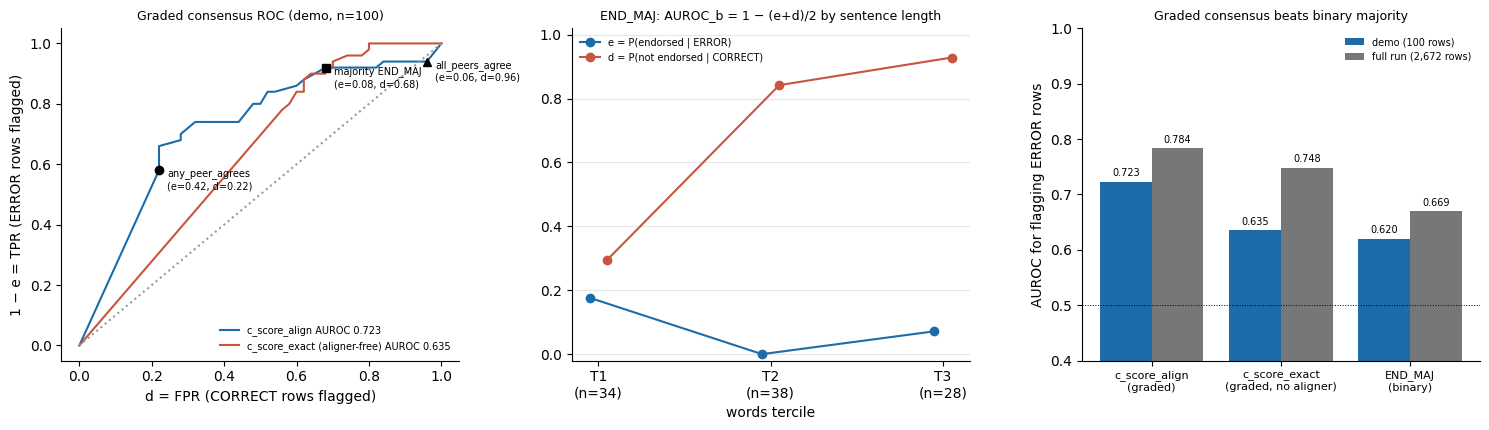

In [15]:
full = data["metrics_agg_full"]
keys = ["auroc_c_score_align", "auroc_b_END_MAJ", "delta_graded_minus_binary", "auroc_c_score_exact",
        "e_maj_R_AB", "d_maj_R_AB", "auroc_b_maj_R_AB", "auroc_b_fam2_R_AB", "auroc_b_plur_R_AB", "strat_auroc_c_score_align_R_AB",
        "net_words_T3_minus_T1", "net_words_T3_minus_T1_delta_e", "net_words_T3_minus_T1_delta_d", "net_ncond_4p_minus_01"]
cmp = pd.DataFrame([{"metric": k, "demo (100 rows)": ma.get(k, np.nan), "full run (2,672 rows)": full.get(k, np.nan)} for k in keys])
print(cmp.round(3).to_string(index=False))
print("\nFull-run verdicts:", json.dumps(data["metadata"]["verdicts_full"], indent=1))
print("Demo NET verdict (words):", A["NET"]["R_AB"]["words_T3_minus_T1"]["verdict"])

C_E, C_D = "#1b6ca8", "#c8553d"
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
# (a) graded ROC with named operating points  (eval.py fig 4)
for nm, tr_, col, au in (("c_score_align", gt["trace"], C_E, g["auroc_c_score_align"]),
                         ("c_score_exact (aligner-free)", gte["trace"], C_D, g["auroc_c_score_exact"])):
    tr = pd.DataFrame(tr_)
    ax[0].plot([0] + tr.d_t.tolist() + [1], [0] + (1 - tr.e_t).tolist() + [1], "-", color=col, label=f"{nm} AUROC {au:.3f}")
for (k, v), mk in zip(g["named_points"].items(), ("o", "s", "^")):
    ax[0].plot(v["d"], 1 - v["e"], mk, color="k", ms=6)
    ax[0].annotate(f"{k.split(' (')[0]}\n(e={v['e']:.2f}, d={v['d']:.2f})", (v["d"], 1 - v["e"]), fontsize=7, xytext=(6, -14), textcoords="offset points")
ax[0].plot([0, 1], [0, 1], ":", color="#999999")
ax[0].set_xlabel("d = FPR (CORRECT rows flagged)")
ax[0].set_ylabel("1 − e = TPR (ERROR rows flagged)")
ax[0].legend(fontsize=7, frameon=False, loc="lower right")
ax[0].set_title(f"Graded consensus ROC (demo, n={len(P)})", fontsize=9)
# (b) e and d of END_MAJ by words tercile  (eval.py fig 1)
order = ["T1", "T2", "T3"]
e_t = [ed_decomposition(P[P.words_t == t].y_AB, P[P.words_t == t].end_MAJ)["e"] for t in order]
d_t = [ed_decomposition(P[P.words_t == t].y_AB, P[P.words_t == t].end_MAJ)["d"] for t in order]
x = np.arange(len(order))
ax[1].plot(x - 0.05, e_t, "o-", color=C_E, label="e = P(endorsed | ERROR)")
ax[1].plot(x + 0.05, d_t, "o-", color=C_D, label="d = P(not endorsed | CORRECT)")
ax[1].set_xticks(x, [f"{t}\n(n={int((P.words_t == t).sum())})" for t in order])
ax[1].set_ylim(-0.02, 1.02)
ax[1].set_xlabel("words tercile")
ax[1].grid(axis="y", alpha=0.3)
ax[1].legend(fontsize=7, frameon=False, loc="upper left")
ax[1].set_title("END_MAJ: AUROC_b = 1 − (e+d)/2 by sentence length", fontsize=9)
# (c) demo vs full AUROCs
lab = ["c_score_align\n(graded)", "c_score_exact\n(graded, no aligner)", "END_MAJ\n(binary)"]
dv = [g["auroc_c_score_align"], g["auroc_c_score_exact"], g["auroc_b_END_MAJ"]]
fv = [full["auroc_c_score_align"], full["auroc_c_score_exact"], full["auroc_b_END_MAJ"]]
xx = np.arange(3)
ax[2].bar(xx - 0.2, dv, 0.4, color=C_E, label="demo (100 rows)")
ax[2].bar(xx + 0.2, fv, 0.4, color="#777777", label="full run (2,672 rows)")
for i in range(3):
    ax[2].text(xx[i] - 0.2, dv[i] + 0.01, f"{dv[i]:.3f}", ha="center", fontsize=7)
    ax[2].text(xx[i] + 0.2, fv[i] + 0.01, f"{fv[i]:.3f}", ha="center", fontsize=7)
ax[2].axhline(0.5, color="k", lw=0.7, ls=":")
ax[2].set_xticks(xx, lab, fontsize=8)
ax[2].set_ylim(0.4, 1.0)
ax[2].set_ylabel("AUROC for flagging ERROR rows")
ax[2].legend(fontsize=7, frameon=False)
ax[2].set_title("Graded consensus beats binary majority", fontsize=9)
for a_ in ax:
    a_.spines["top"].set_visible(False)
    a_.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()